Split the time series in a training set and a test set

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import month_plot, seasonal_plot

from statsmodels.tsa.holtwinters import ExponentialSmoothing

import pmdarima as pm  # auto_arima
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error

from statsmodels.stats.diagnostic import acorr_ljungbox

from scipy.stats import boxcox, boxcox_normmax
from scipy.special import inv_boxcox

import warnings
warnings.filterwarnings("ignore")

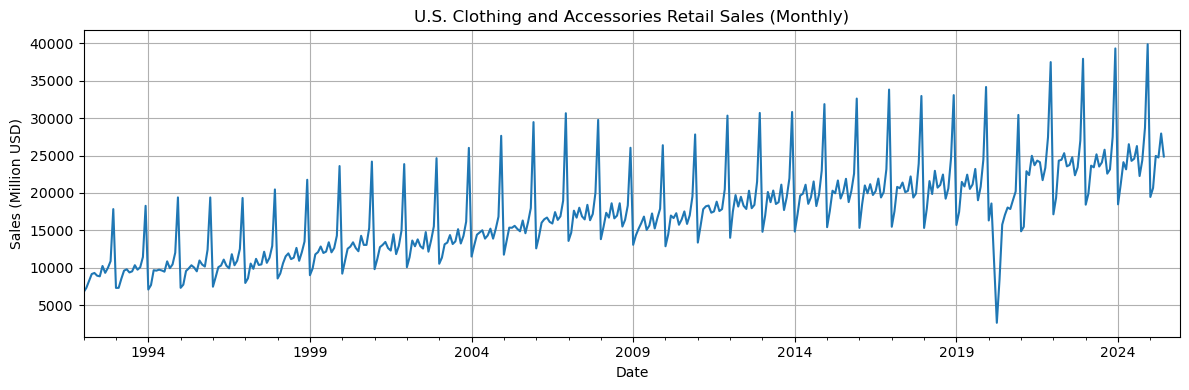

Training set: 1992-01-01 to 2019-12-01
Test set:     2020-01-01 to 2024-12-01


In [ ]:
# === Load and clean data ===
file_path = "SeriesReport-202507261617.csv"
df = pd.read_csv(file_path, skiprows=7)
df.columns = ['Period', 'Value']
df['Period'] = pd.to_datetime(df['Period'], format='%b-%Y')
df = df.sort_values('Period')
df.set_index('Period', inplace=True)
df = df.asfreq('MS')  # monthly start frequency

# === Plot full series ===
df['Value'].plot(figsize=(12, 4), title='U.S. Clothing and Accessories Retail Sales (Monthly)')
plt.ylabel('Sales (Million USD)')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()

# === Split into train and test sets ===
# Use last 4.5 years (54 months) as test set: Jan 2020 – Jun 2024
train = df.loc[:'2019-12-01']
test = df.loc['2020-01-01':'2024-12-01']

print("Training set:", train.index.min().date(), "to", train.index.max().date())
print("Test set:    ", test.index.min().date(), "to", test.index.max().date())

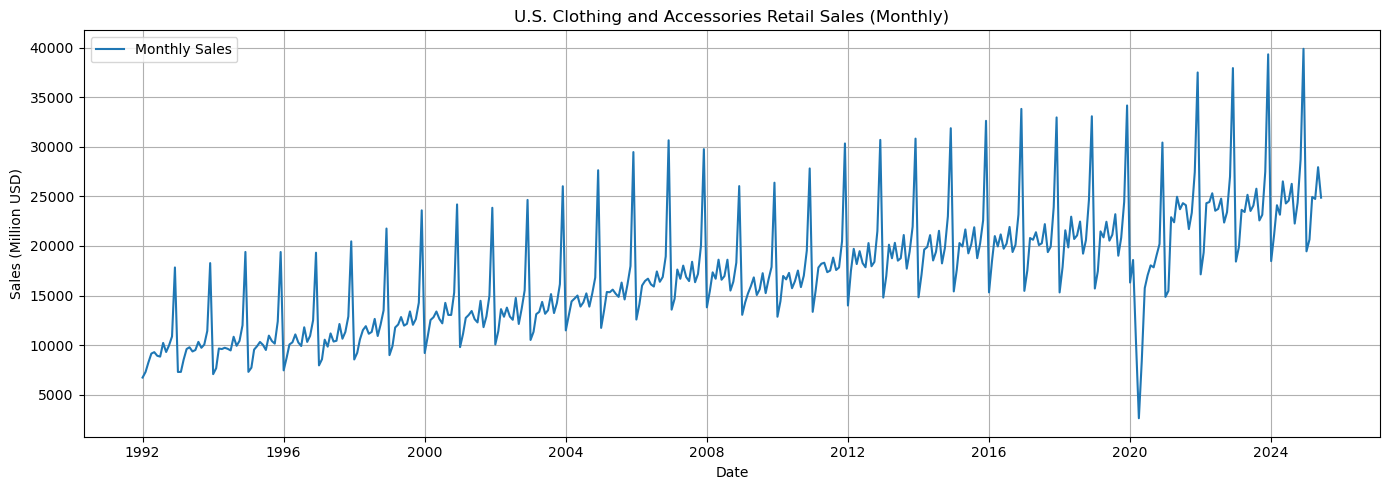

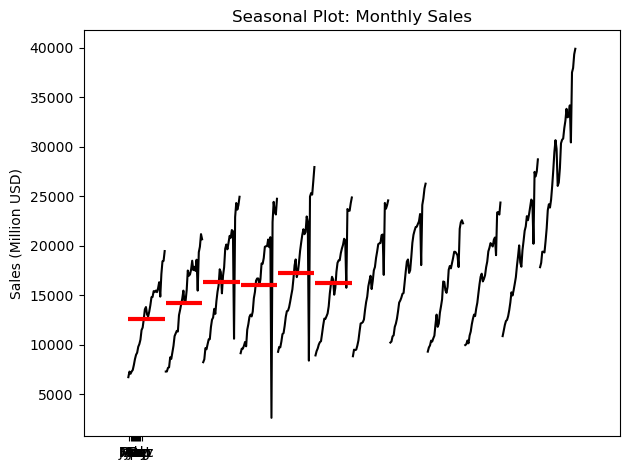

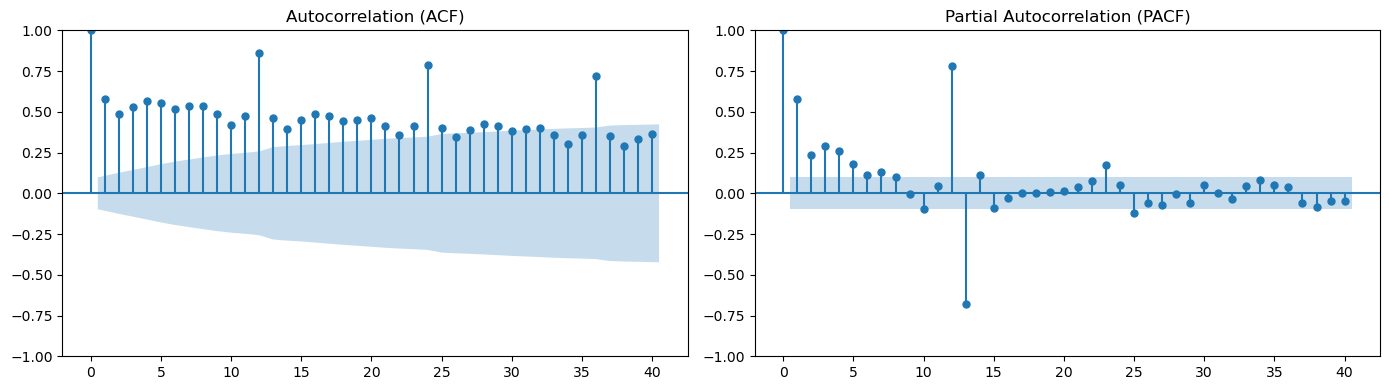

In [12]:
# === Time Series Plot ===
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Value'], label='Monthly Sales')
plt.title('U.S. Clothing and Accessories Retail Sales (Monthly)')
plt.ylabel('Sales (Million USD)')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Seasonal Plot ===
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_plot(df['Value'], ylabel='Sales (Million USD)')
plt.title('Seasonal Plot: Monthly Sales')
plt.xticks(ticks=np.arange(1, 13), labels=month_names)
plt.tight_layout()
plt.show()

# === Autocorrelation and Partial Autocorrelation Plots ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['Value'].dropna(), ax=axes[0], lags=40)
axes[0].set_title('Autocorrelation (ACF)')
plot_pacf(df['Value'].dropna(), ax=axes[1], lags=40, method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')
plt.tight_layout()
plt.show()

Apply the most appropriate transformation and/or adjustments

Optimal Box-Cox lambda: 0.0531


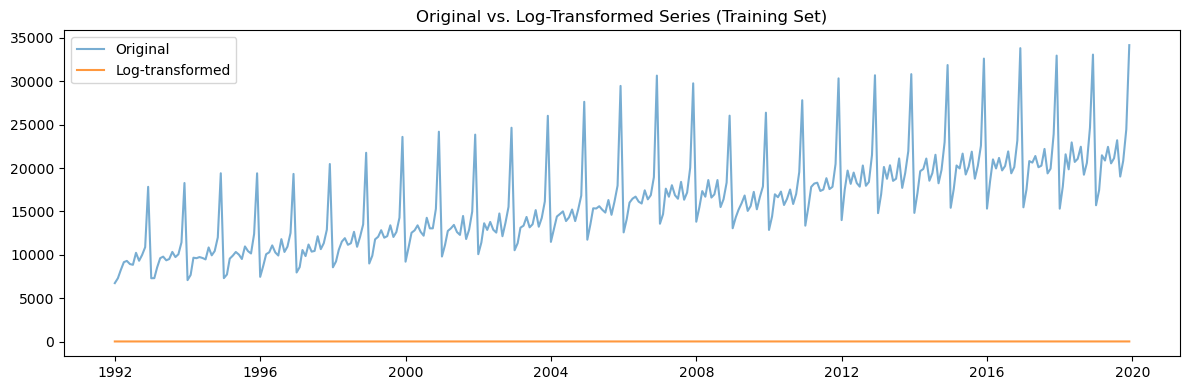

In [13]:
# Extract training values
train_values = train['Value'].values

# Apply Box-Cox to training data
transformed, fitted_lambda = boxcox(train_values)

print(f"Optimal Box-Cox lambda: {fitted_lambda:.4f}")

# === Apply log transform since lambda ≈ 0 ===
log_train = np.log(train['Value'])
log_test = np.log(test['Value'])  # not required now, but useful for comparisons

# Plot comparison
plt.figure(figsize=(12, 4))
plt.plot(train.index, train['Value'], label='Original', alpha=0.6)
plt.plot(log_train.index, log_train, label='Log-transformed', alpha=0.8)
plt.title('Original vs. Log-Transformed Series (Training Set)')
plt.legend()
plt.tight_layout()
plt.show()

Present and discuss the parameters of the final ETS model

Final ETS model: ETS(A,A,M)
RMSE on test set: 3844.6667
Ljung-Box test (lag 12):
      lb_stat     lb_pvalue
12  52.678437  4.698929e-07


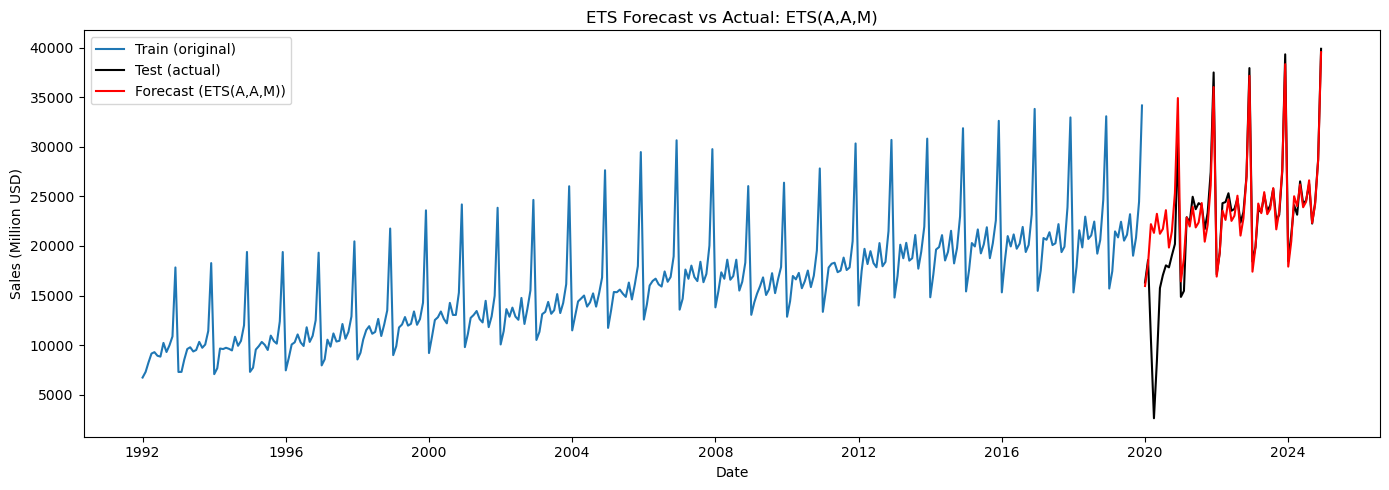

In [14]:
# === Fit ETS(A,A,A) ===
ets_aaa = ExponentialSmoothing(
    log_train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

# Forecast (log)
log_forecast_aaa = ets_aaa.forecast(len(test))

# Bias-adjusted forecast (original scale)
resid_var_aaa = np.var(ets_aaa.resid, ddof=1)
forecast_aaa = np.exp(log_forecast_aaa + 0.5 * resid_var_aaa)

# RMSE
rmse_aaa = np.sqrt(mean_squared_error(test['Value'], forecast_aaa))

# === Fit ETS(A,A,M) ===
ets_aam = ExponentialSmoothing(
    log_train,
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit(optimized=True)

# Forecast (log)
log_forecast_aam = ets_aam.forecast(len(test))
resid_var_aam = np.var(ets_aam.resid, ddof=1)
forecast_aam = np.exp(log_forecast_aam + 0.5 * resid_var_aam)

# RMSE
rmse_aam = np.sqrt(mean_squared_error(test['Value'], forecast_aam))

# === Select final model ===
final_model = ets_aaa if rmse_aaa < rmse_aam else ets_aam
final_forecast = forecast_aaa if rmse_aaa < rmse_aam else forecast_aam
final_model_name = "ETS(A,A,A)" if rmse_aaa < rmse_aam else "ETS(A,A,M)"
final_rmse = min(rmse_aaa, rmse_aam)

# === Print results ===
print(f"Final ETS model: {final_model_name}")
print(f"RMSE on test set: {final_rmse:.4f}")
print("Ljung-Box test (lag 12):")
print(acorr_ljungbox(final_model.resid, lags=[12], return_df=True))

# === Plot forecast ===
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['Value'], label='Train (original)')
plt.plot(test.index, test['Value'], label='Test (actual)', color='black')
plt.plot(test.index, final_forecast, label=f'Forecast ({final_model_name})', color='red')
plt.title(f'ETS Forecast vs Actual: {final_model_name}')
plt.xlabel('Date')
plt.ylabel('Sales (Million USD)')
plt.legend()
plt.tight_layout()
plt.show()

Present and discuss the parameters of the final ARIMA model

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=-1355.369, Time=1.16 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-1132.089, Time=0.08 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-1266.918, Time=0.35 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-1342.470, Time=0.24 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=-1355.870, Time=0.71 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=-1299.793, Time=0.39 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=-1355.675, Time=2.21 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=-1336.597, Time=0.72 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=-1353.793, Time=1.94 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=-1347.338, Time=0.75 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=-1354.837, Time=0.79 sec
 ARIMA(3,1,2)(0,1,1)[12]             : AIC=-1357.034, Time=1.40 sec
 ARIMA(3,1,2)(0,1,0)[12]             : AIC=-1303.781, Time=0.70 sec
 ARIMA(3,1,2)(1,1,1)[12]             : AIC=inf, Time=1.73 sec
 ARIMA(3,1,

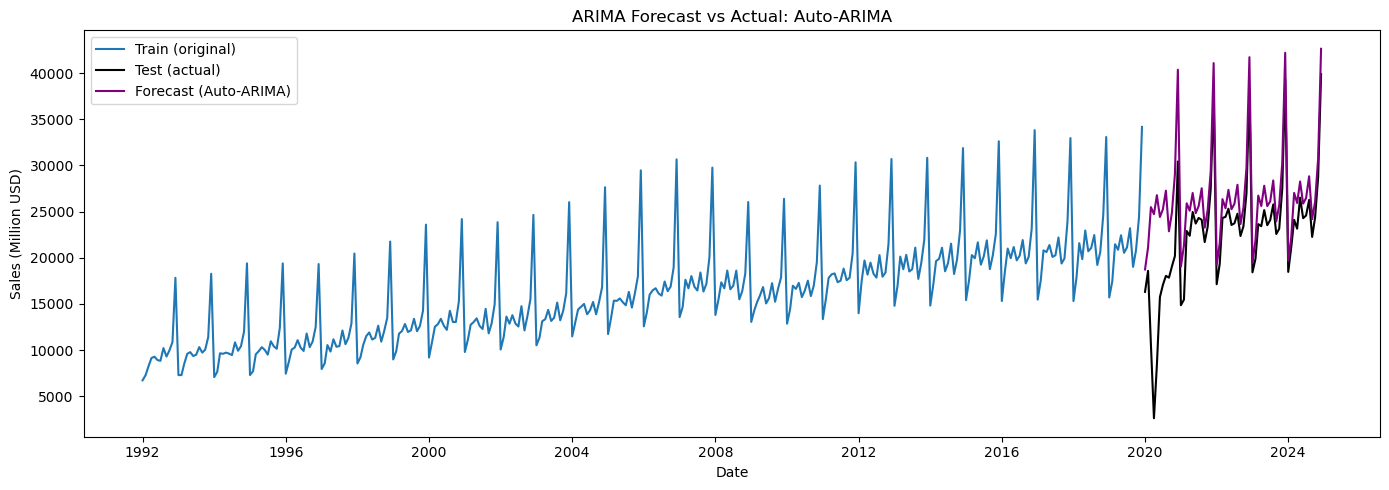

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# === Auto ARIMA ===
auto_model = pm.auto_arima(
    log_train,
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

# Forecast on log scale
log_forecast_auto = auto_model.predict(n_periods=len(test))

# Bias-adjusted inverse transform
resid_var_auto = np.var(auto_model.resid(), ddof=1)
forecast_auto = np.exp(log_forecast_auto + 0.5 * resid_var_auto)

# RMSE
rmse_auto = np.sqrt(mean_squared_error(test['Value'], forecast_auto))


# === Manual model: SARIMA(1,1,0)(1,1,1)[12] ===
manual_model = SARIMAX(
    log_train,
    order=(1,1,0),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Forecast (log)
log_forecast_manual = manual_model.forecast(steps=len(test))
resid_var_manual = np.var(manual_model.resid, ddof=1)
forecast_manual = np.exp(log_forecast_manual + 0.5 * resid_var_manual)

# RMSE
rmse_manual = np.sqrt(mean_squared_error(test['Value'], forecast_manual))


# === Final model selection ===
if rmse_auto < rmse_manual:
    final_model = 'Auto-ARIMA'
    forecast = forecast_auto
    final_rmse = rmse_auto
    final_resid = auto_model.resid()
else:
    final_model = 'Manual ARIMA(1,1,0)(1,1,1)[12]'
    forecast = forecast_manual
    final_rmse = rmse_manual
    final_resid = manual_model.resid

print(f"Final ARIMA model: {final_model}")
print(f"Test set RMSE: {final_rmse:.4f}")
print("\nLjung-Box test (lag 12):")
print(acorr_ljungbox(final_resid, lags=[12], return_df=True))

# === Plot forecast ===
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['Value'], label='Train (original)')
plt.plot(test.index, test['Value'], label='Test (actual)', color='black')
plt.plot(test.index, forecast, label=f'Forecast ({final_model})', color='purple')
plt.title(f'ARIMA Forecast vs Actual: {final_model}')
plt.xlabel('Date')
plt.ylabel('Sales (Million USD)')
plt.legend()
plt.tight_layout()
plt.show()

Final forecast

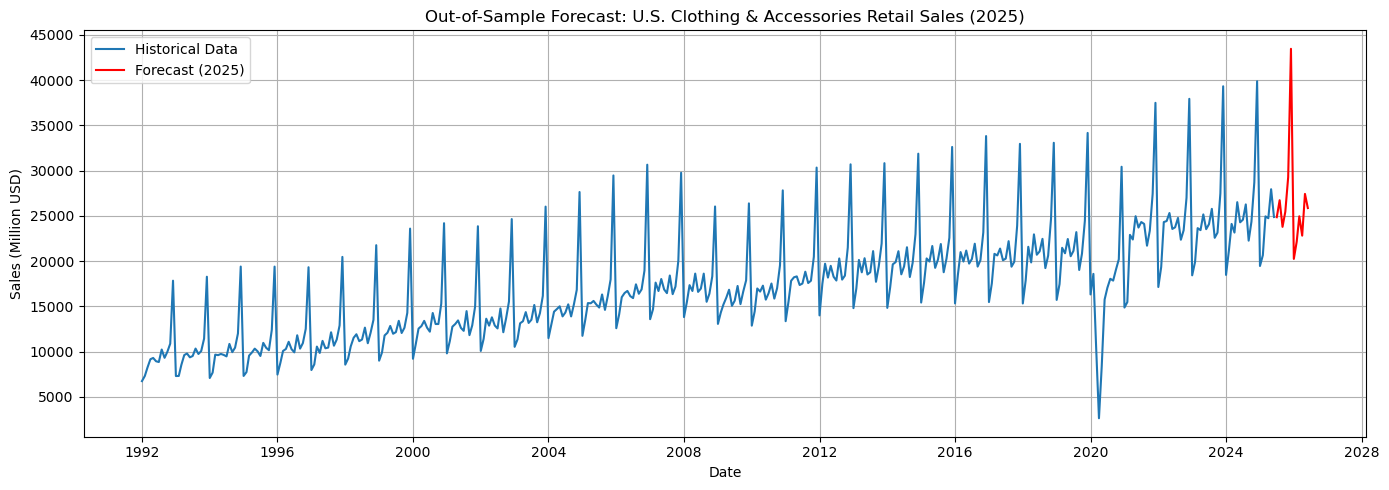

In [18]:
# === Refit final ETS(A,A,M) model to full dataset (log-transformed) ===
log_full = np.log(df['Value'])

# Drop NaN values to ensure strictly positive input for multiplicative components
log_full_clean = log_full.dropna()

final_model_full = ExponentialSmoothing(
    log_full_clean,
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit(optimized=True)

# Forecast 12 months ahead (Jan 2025 – Dec 2025)
log_forecast_future = final_model_full.forecast(steps=12)

# Bias-adjusted inverse transform
resid_var_full = np.var(final_model_full.resid, ddof=1)
forecast_future = np.exp(log_forecast_future + 0.5 * resid_var_full)

# === Plot full series with forecast ===
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Value'], label='Historical Data')
plt.plot(forecast_future.index, forecast_future, label='Forecast (2025)', color='red')
plt.title('Out-of-Sample Forecast: U.S. Clothing & Accessories Retail Sales (2025)')
plt.xlabel('Date')
plt.ylabel('Sales (Million USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()